# **Feed Forward Network con PyTorch**
* Oscar Ivanovich Avila Chiu 35676

En esta actividad crearás, entrenarás y evaluarás una red neuronal de arquitectura feed forward (o MLP) utilizando PyTorch y el conjunto de datos MNIST.

In [115]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import gzip
from pathlib import Path
import seaborn as sns
import math
import kagglehub
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [116]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## MNIST dataset

This is a classic dataset in machine learning, consisting of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is a 28x28 pixel grayscale image, which can be flattened into a 784-dimensional vector for input into our neural network. The goal is to classify each image into one of the 10 digit classes. The following code will load them into memory.

In [117]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [118]:
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('data')

In [119]:
class MNIST_Digits(Dataset):
    def __init__(self, X, y):
      self.X = torch.tensor(X.reshape(-1, 28*28), dtype=torch.float32).to(device)
      self.y = torch.tensor(y.squeeze(), dtype=torch.long).to(device)

    def __len__(self):
      return len(self.y)

    def __getitem__(self, idx):
      return self.X[idx], self.y[idx]

In [120]:
train_data = MNIST_Digits(x_train, y_train)
val_data = MNIST_Digits(x_val, y_val)
test_data = MNIST_Digits(x_test, y_test)

print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Test data size: {len(test_data)}")

Train data size: 50000
Validation data size: 10000
Test data size: 10000


We can also use matplotlib to visualize the images in the dataset. Each image is a 28x28 pixel grayscale image, which can be displayed using the `imshow` function from matplotlib.

Every time you run this cell, a random number from the training set will be displayed. You can run it multiple times to see different images from the dataset.

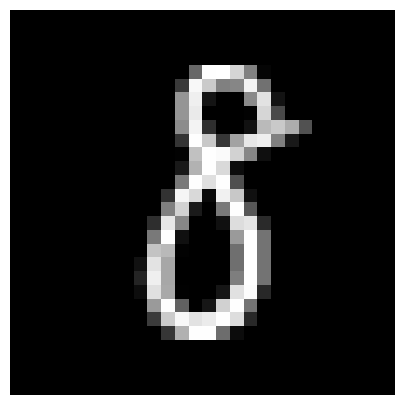

'Label: 8'

In [121]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

## Defining the Neural Network

In [122]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, patience, delta):
    training_losses = []
    validation_losses = []

    val_loss_history = []

    for epoch in range(_num_epochs):
        _model.train()
        running_loss = 0.0
        for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch + 1}/{_num_epochs}"):
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            running_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_loss / len(_train_loader.dataset)
        training_losses.append(epoch_train_loss)

        _model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)

                preds = torch.argmax(val_outputs, dim=1)
                correct += (preds == y_val).sum().item()
                total += y_val.size(0)

        epoch_val_loss = val_loss / len(_val_loader.dataset)
        epoch_val_acc = correct / total
        validation_losses.append(epoch_val_loss)
        val_loss_history.append(epoch_val_loss)

        print(f"Epoch {epoch+1}: "
              f"Train Loss: {epoch_train_loss:.4f}, "
              f"Val Loss: {epoch_val_loss:.4f}, "
              f"Val Accuracy: {epoch_val_acc:.4f}")
        print("")

        # Early stopping con delta
        if len(val_loss_history) > patience:
            loss_diff = abs(val_loss_history[-patience-1] - val_loss_history[-1])
            if loss_diff < delta and val_loss_history[-patience-1] >= val_loss_history[-1]:
                print(f"Early stopping triggered at epoch {epoch+1} (delta={delta}, patience={patience})")
                break

    return training_losses, validation_losses

In [126]:
# MODELO 1
model1 = nn.Sequential(
  nn.Linear(28*28, 512),
  nn.ReLU(),
  nn.Linear(512, 256),
  nn.ReLU(),
  nn.Linear(256, 10)
).to(device)

criterion = nn.CrossEntropyLoss()

# CAMBIOS ENTRE MODELOS
optimizer = optim.Adam(model1.parameters(), lr=0.1, weight_decay=1e-4)

num_epochs = 10
patience = 5
delta = 0.001
batch_size = 100

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)

train_losses, val_losses = train(
    model1,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    patience,
    delta)

Epoch 1/10: 100%|██████████| 500/500 [00:05<00:00, 94.40it/s]


Epoch 1: Train Loss: 328.3179, Val Loss: 2.3061, Val Accuracy: 0.1030



Epoch 2/10: 100%|██████████| 500/500 [00:05<00:00, 89.01it/s]


Epoch 2: Train Loss: 2.3062, Val Loss: 2.3054, Val Accuracy: 0.0990



Epoch 3/10: 100%|██████████| 500/500 [00:07<00:00, 64.91it/s]


...

Epoch 6: Train Loss: 2.3076, Val Loss: 2.3093, Val Accuracy: 0.1030



Epoch 7/10: 100%|██████████| 500/500 [00:19<00:00, 25.13it/s]


Epoch 7: Train Loss: 8.5033, Val Loss: 2.3032, Val Accuracy: 0.1090



Epoch 8/10: 100%|██████████| 500/500 [00:21<00:00, 23.15it/s]


Epoch 8: Train Loss: 2.3077, Val Loss: 2.3051, Val Accuracy: 0.1064

Early stopping triggered at epoch 8 (delta=0.001, patience=5)


In [125]:
# MODELO 2
model2 = nn.Sequential(
  nn.Linear(28*28, 512),
  nn.ReLU(),
  nn.Linear(512, 256),
  nn.ReLU(),
  nn.Dropout(0.2),
  nn.Linear(256, 10)
).to(device)

criterion = nn.CrossEntropyLoss()

# CAMBIOS ENTRE MODELOS
optimizer = optim.Adam(model2.parameters(), lr=0.01, weight_decay=1e-4)

num_epochs = 30
patience = 5
delta = 0.001
batch_size = 200

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)

train_losses, val_losses = train(
    model2,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    patience,
    delta)

Epoch 1/30: 100%|██████████| 250/250 [00:06<00:00, 37.38it/s]


Epoch 1: Train Loss: 6.6722, Val Loss: 0.7408, Val Accuracy: 0.7180



Epoch 2/30: 100%|██████████| 250/250 [00:04<00:00, 59.15it/s]


Epoch 2: Train Loss: 0.7575, Val Loss: 0.6479, Val Accuracy: 0.7449



Epoch 3/30: 100%|██████████| 250/250 [00:05<00:00, 47.41it/s]


...

Epoch 28: Train Loss: 1.4468, Val Loss: 1.0861, Val Accuracy: 0.6382



Epoch 29/30: 100%|██████████| 250/250 [00:10<00:00, 22.95it/s]


Epoch 29: Train Loss: 1.3125, Val Loss: 1.2343, Val Accuracy: 0.6175



Epoch 30/30: 100%|██████████| 250/250 [00:10<00:00, 23.94it/s]


Epoch 30: Train Loss: 1.1864, Val Loss: 1.0356, Val Accuracy: 0.6284



In [127]:
# MODELO 3
model3 = nn.Sequential(
  nn.Linear(28*28, 512),
  nn.ReLU(),
  nn.Dropout(0.3),
  nn.Linear(512, 256),
  nn.ReLU(),
  nn.Dropout(0.2),
  nn.Linear(256, 10)
).to(device)

criterion = nn.CrossEntropyLoss()

# CAMBIOS ENTRE MODELOS
optimizer = optim.Adam(model3.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 50
patience = 5
delta = 0.001
batch_size = 300

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)

train_losses, val_losses = train(
    model3,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    patience,
    delta)

Epoch 1/50: 100%|██████████| 167/167 [00:04<00:00, 36.71it/s]


Epoch 1: Train Loss: 0.8617, Val Loss: 0.1486, Val Accuracy: 0.9551



Epoch 2/50: 100%|██████████| 167/167 [00:04<00:00, 39.02it/s]


Epoch 2: Train Loss: 0.2190, Val Loss: 0.1281, Val Accuracy: 0.9632



Epoch 3/50: 100%|██████████| 167/167 [00:05<00:00, 30.46it/s]


...

Epoch 15: Train Loss: 0.0739, Val Loss: 0.0900, Val Accuracy: 0.9787



Epoch 16/50: 100%|██████████| 167/167 [00:06<00:00, 27.75it/s]


Epoch 16: Train Loss: 0.0678, Val Loss: 0.1027, Val Accuracy: 0.9735



Epoch 17/50: 100%|██████████| 167/167 [00:05<00:00, 29.02it/s]


Epoch 17: Train Loss: 0.0725, Val Loss: 0.0888, Val Accuracy: 0.9794

Early stopping triggered at epoch 17 (delta=0.001, patience=5)


In [129]:
def evaluate_model(model, test_loader, criterion):
    model.eval()
    correct = 0
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / len(test_loader.dataset)
    return test_loss, test_acc

# Evaluación de los 3 modelos
test_loss1, test_acc1 = evaluate_model(model1, test_loader, criterion)
test_loss2, test_acc2 = evaluate_model(model2, test_loader, criterion)
test_loss3, test_acc3 = evaluate_model(model3, test_loader, criterion)

print(f"Modelo 1 - Test Loss: {test_loss1:.4f}, Test Accuracy: {test_acc1:.4f}")
print(f"Modelo 2 - Test Loss: {test_loss2:.4f}, Test Accuracy: {test_acc2:.4f}")
print(f"Modelo 3 - Test Loss: {test_loss3:.4f}, Test Accuracy: {test_acc3:.4f}")

# Segun mayor accuracy
best_model = model1
best_acc = test_acc1

if test_acc2 > best_acc:
    best_model = model2
    best_acc = test_acc2
if test_acc3 > best_acc:
    best_model = model3
    best_acc = test_acc3

print(f"\nMejor modelo: {best_model} \nDebido a Mejor Accuracy = {best_acc:.4f}")

Modelo 1 - Test Loss: 2.3040, Test Accuracy: 0.1135
Modelo 2 - Test Loss: 1.0355, Test Accuracy: 0.6234
Modelo 3 - Test Loss: 0.0811, Test Accuracy: 0.9773

Mejor modelo: Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=256, out_features=10, bias=True)
) 
Debido a Mejor Accuracy = 0.9773


## Training the Neural Network

We also need to define our loss function. For multi-class classification, a common choice is the softmax cross-entropy loss. This loss function combines the softmax activation function with the cross-entropy loss, which measures the difference between the predicted probabilities and the true labels. The following function will compute the softmax cross-entropy loss and also calculate the gradients needed for backpropagation.

Let's also create the accuracy function to measure the performance of our model on the validation set during training.

Let's now define the training loop for our neural network. In each epoch, we will iterate over the mini-batches of the training data, perform a forward pass to compute the predictions, calculate the loss and gradients using the softmax cross-entropy function, perform a backward pass to compute the gradients for each layer, and then update the weights using gradient descent. After each epoch, we will also evaluate the accuracy on the validation set.

Let's now define our neural network architecture. It has three layers:
- Input layer with 784 neurons (one for each pixel in the input image)
- Hidden layer with 200 neurons and ReLU activation
- Output layer with 10 neurons (one for each class) and no activation function (since we will apply the softmax function in the loss function)

Set up our training parameters and start training the model.

## Testing the model

We can also visualize the confusion matrix.

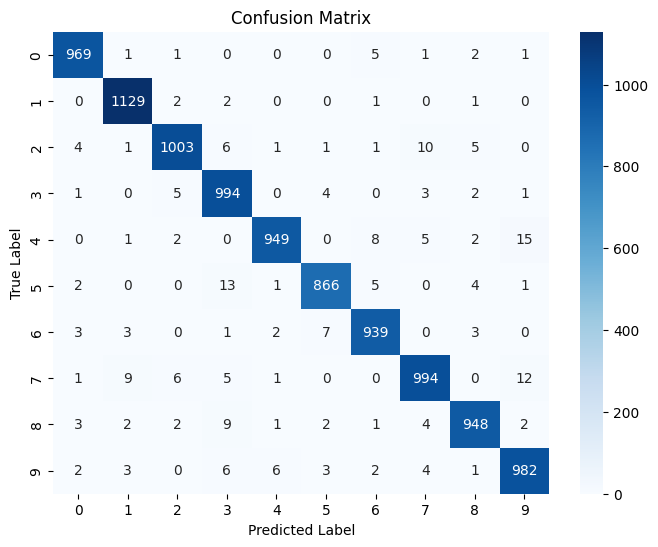

In [134]:
# Evaluación final con best_model
best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = best_model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())

# Convertir listas a arrays
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# Matriz de confusión
conf_matrix = np.zeros((10, 10), dtype=int)
for true_label, pred_label in zip(y_true, y_pred):
    conf_matrix[true_label, pred_label] += 1

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [133]:
# Cálculo de métricas por clase
precision = np.zeros(10)
recall = np.zeros(10)
f1_score = np.zeros(10)

# Se van agregando segun la etiqueta
for i in range(10):
  tp = conf_matrix[i, i]
  fp = conf_matrix[:, i].sum() - tp
  fn = conf_matrix[i, :].sum() - tp
  precision[i] = tp / (tp + fp) if (tp + fp) > 0 else 0
  recall[i] = tp / (tp + fn) if (tp + fn) > 0 else 0
  f1_score[i] = (2 * precision[i] * recall[i]) / (precision[i] + recall[i]) if (precision[i] + recall[i]) > 0 else 0

# Accuracy global
accuracy_global = np.trace(conf_matrix) / np.sum(conf_matrix)

# Mostrar resultados
print(f"Global Accuracy: {accuracy_global:.4f}\n")
for i in range(10):
    print(f"Class {i}: Precision = {precision[i]:.4f}, Recall = {recall[i]:.4f}, F1-score = {f1_score[i]:.4f}")

Global Accuracy: 0.9773

Class 0: Precision = 0.9838, Recall = 0.9888, F1-score = 0.9863
Class 1: Precision = 0.9826, Recall = 0.9947, F1-score = 0.9886
Class 2: Precision = 0.9824, Recall = 0.9719, F1-score = 0.9771
Class 3: Precision = 0.9595, Recall = 0.9842, F1-score = 0.9717
Class 4: Precision = 0.9875, Recall = 0.9664, F1-score = 0.9768
Class 5: Precision = 0.9807, Recall = 0.9709, F1-score = 0.9758
Class 6: Precision = 0.9761, Recall = 0.9802, F1-score = 0.9781
Class 7: Precision = 0.9736, Recall = 0.9669, F1-score = 0.9702
Class 8: Precision = 0.9793, Recall = 0.9733, F1-score = 0.9763
Class 9: Precision = 0.9684, Recall = 0.9732, F1-score = 0.9708


# **Reflexión personal**

Esta actividad me hizo darme cuenta de que, cuando no se usa GridSearchCV, uno debe probar todas las combinaciones posibles para encontrar el resultado que nos otorgue mayor accuracy y menores errores en validación. Con PyTorch noté que facilita muchos aspectos, como la implementación de ReLU, redes neuronales y funciones propias de la librería.

Sin duda, experimentar con métricas, capas ocultas y parámetros relacionados me recordó que el verdadero modelo se construye probando y ajustando hasta llegar a un punto satisfactorio. Además, medidas como early stopping ayudaron a que no se ejecutaran todas las épocas, ahorrando tiempo y recursos computacionales. Considero que al entrenar un modelo de ML, el tiempo es un factor valioso para tener más probabilidades de encontrar un mejor modelo.